Fit: A = 1521619.8333 * C + -75628.1933
Estimated C for area 4522598.6 = 3.022 mM
Estimated C for area 4374456.5 = 2.925 mM


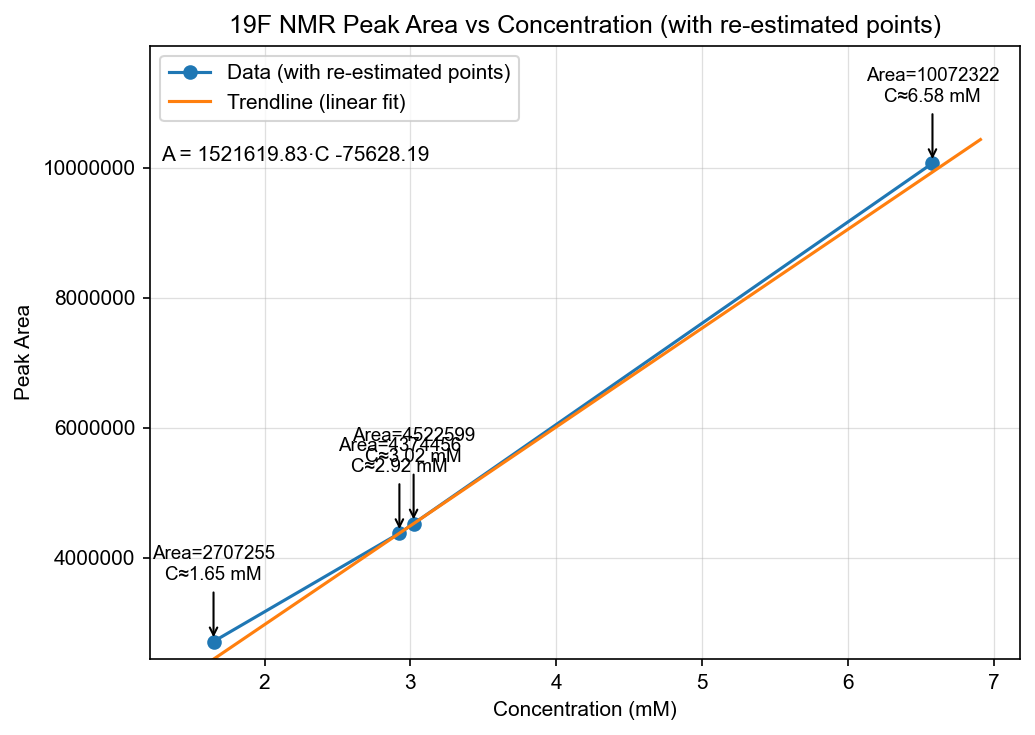

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

# ----------------------------
# 1) 输入数据
# ----------------------------
# 三点（浓度 mM - 峰面积，保持同一量级）
C = np.array([6.58, 3.29, 1.65], dtype=float)
A = np.array([10072322.0, 4522598.6, 2707255.3], dtype=float)

# 在 “3.29 mM” 附近新增的一条峰面积（与第二个点同量级）
A_extra = 4374456.5

# ----------------------------
# 2) 拟合趋势线：A = slope*C + intercept
# ----------------------------
slope, intercept = np.polyfit(C, A, 1)

def area_to_conc(area: float) -> float:
    """用趋势线把峰面积反推浓度"""
    return (area - intercept) / slope

# 反推两个“3.29 mM附近”的真实浓度（一个是现有点的面积，一个是新增面积）
C_exist = area_to_conc(4522598.6)
C_extra = area_to_conc(A_extra)

print(f"Fit: A = {slope:.4f} * C + {intercept:.4f}")
print(f"Estimated C for area 4522598.6 = {C_exist:.3f} mM")
print(f"Estimated C for area {A_extra:.1f} = {C_extra:.3f} mM")

# 用两个估计浓度替换原来的 3.29 mM 单点
C_all = np.array([6.58, C_exist, C_extra, 1.65], dtype=float)
A_all = np.array([10072322.0, 4522598.6, A_extra, 2707255.3], dtype=float)

# 为了让线图看起来顺滑，按浓度排序
idx = np.argsort(C_all)
C_all_sorted = C_all[idx]
A_all_sorted = A_all[idx]

# ----------------------------
# 3) 字体设置：优先 Arial（没有就回退）
# ----------------------------
available_fonts = {f.name for f in fm.fontManager.ttflist}
plt.rcParams["font.family"] = "Arial" if "Arial" in available_fonts else "DejaVu Sans"

# ----------------------------
# 4) 画图：数据线 + 趋势线 + 标注
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

# 数据线（连接后的线图）+ 散点
ax.plot(C_all_sorted, A_all_sorted, marker="o", linewidth=1.5, label="Data (with re-estimated points)")

# 趋势线
x_fit = np.linspace(min(C_all_sorted) * 0.9, max(C_all_sorted) * 1.05, 200)
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, linewidth=1.5, label="Trendline (linear fit)")

# 坐标轴与标题
ax.set_xlabel("Concentration (mM)")
ax.set_ylabel("Peak Area")
ax.set_title("19F NMR Peak Area vs Concentration (with re-estimated points)")

# 给上边留一点空间，防止上方标注被截断
ax.set_ylim(min(A_all_sorted) * 0.9, max(A_all_sorted) * 1.18)

# 先放置图例于左上，避免自动选择覆盖
leg = ax.legend(loc='upper left', frameon=True)

# 在图例下方显示拟合方程
eq_text = f"A = {slope:.2f}·C {intercept:+.2f}"
fig.canvas.draw()  # 计算图例位置用
renderer = fig.canvas.get_renderer()
bbox = leg.get_window_extent(renderer)
bbox_axes = bbox.transformed(ax.transAxes.inverted())
# 让方程紧贴图例下方，留一点间隙
x_eq = bbox_axes.x0
y_eq = bbox_axes.y0 - 0.03
ax.text(x_eq, y_eq, eq_text, transform=ax.transAxes, va="top", fontsize=10)

# 为每个数据点添加箭头与文字（Area 与 C）
xrange = C_all_sorted.max() - C_all_sorted.min()
yrange = A_all_sorted.max() - A_all_sorted.min()
for cx, ay in zip(C_all_sorted, A_all_sorted):
    ax.annotate(f"Area={ay:.0f}\nC≈{cx:.2f} mM",
                xy=(cx, ay),
                xytext=(cx, ay + 0.12 * yrange),
                ha='center', va='bottom',
                arrowprops=dict(arrowstyle="->", lw=1),
                fontsize=9)

ax.grid(True, linewidth=0.6, alpha=0.4)
ax.ticklabel_format(style='plain', axis='y')  # 避免科学计数法
plt.tight_layout()
plt.show()

Quadratic fit: y = 2.10e+05 x^2 + -5.58e+05 x + 5.15e+05


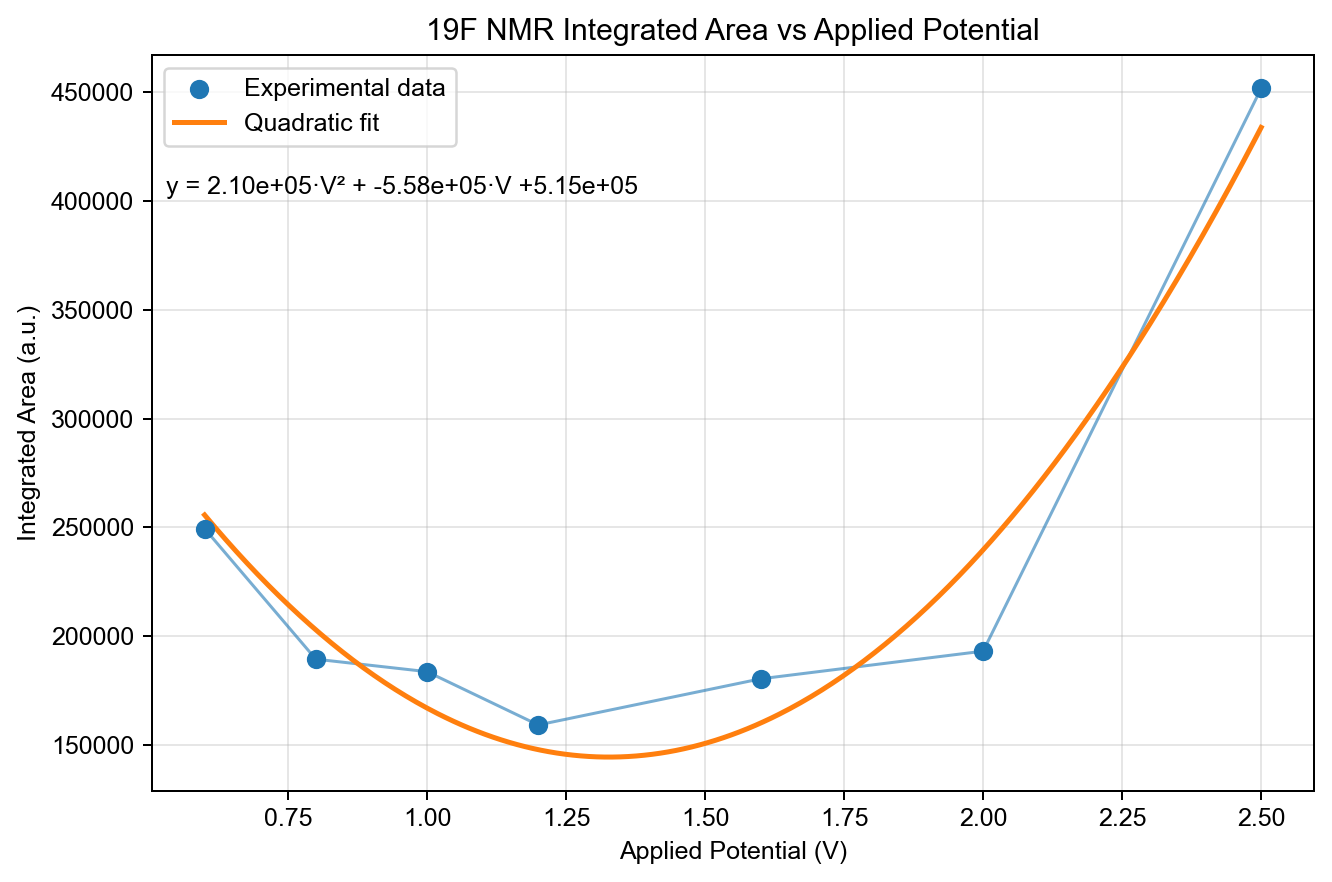

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

# =========================
# 1) 数据（你只需要改这里）
# =========================
potential_V = np.array([0.6, 0.8, 1.0, 1.2, 1.6, 2.0, 2.5], dtype=float)
area = np.array([249491.7, 189507.7, 183775.6, 159295.9,
                 180485.0, 193184.4, 451695.8], dtype=float)

# =========================
# 2) 字体设置（优先 Arial）
# =========================
available_fonts = {f.name for f in fm.fontManager.ttflist}
plt.rcParams["font.family"] = "Arial" if "Arial" in available_fonts else "DejaVu Sans"

# =========================
# 3) 排序（防止折线乱连）
# =========================
idx = np.argsort(potential_V)
x = potential_V[idx]
y = area[idx]

# =========================
# 4) 二次曲线拟合
# =========================
coeffs = np.polyfit(x, y, 2)   # 二次拟合
a, b, c = coeffs

x_fit = np.linspace(x.min(), x.max(), 400)
y_fit = a * x_fit**2 + b * x_fit + c

print(f"Quadratic fit: y = {a:.2e} x^2 + {b:.2e} x + {c:.2e}")

# =========================
# 5) 绘图
# =========================
fig, ax = plt.subplots(figsize=(7.5, 5.0), dpi=180)

# 原始数据
ax.scatter(x, y, s=45, label="Experimental data", zorder=3)
ax.plot(x, y, linewidth=1.2, alpha=0.6)

# 二次拟合曲线
ax.plot(x_fit, y_fit, linewidth=2.0, label="Quadratic fit")

# =========================
# 6) 图形美化
# =========================
ax.set_xlabel("Applied Potential (V)")
ax.set_ylabel("Integrated Area (a.u.)")
ax.set_title("19F NMR Integrated Area vs Applied Potential")
ax.grid(True, alpha=0.35, linewidth=0.7)

# 图例与方程：方程置于图例正下方
leg = ax.legend(loc='upper left', frameon=True)
eq_text = (
    f"y = {a:.2e}·V² + {b:.2e}·V {c:+.2e}"
)
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
bbox = leg.get_window_extent(renderer)
bbox_axes = bbox.transformed(ax.transAxes.inverted())
x_eq = bbox_axes.x0
y_eq = bbox_axes.y0 - 0.03
ax.text(x_eq, y_eq, eq_text, transform=ax.transAxes, va="top", fontsize=10)

plt.tight_layout()
plt.show()
